In [1]:
import pandas as pd

In [2]:
import sys
sys.path.append('/home/evlasova/mirpy')

In [3]:
import sys
sys.path.append('/home/evlasova/mirpy')
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.common.clonotype import ClonotypeAA

In [4]:
def get_sample_info(sample_name):
    data_path = f'/projects/immunestatus/rheum/tcrempnet_b27pos_k4_upd'
    summary = pd.read_csv(f'{data_path}/{sample_name}_summary_tcrempnet.tsv', sep='\t')
    # summary = summary[summary.cluster_size > 4]
    c0 = 857708
    c15 = len(pd.read_csv(
        f'/projects/immunestatus/rheum/airr_format/{sample_name}.tsv', sep='\t'))
    print(f'''
    sample: {sample_name}
    clusters: {len(summary)}
    overall from background: {c0}
    overall from sample: {c15}
    ''')
    return summary, c0, c15

In [5]:
as_seqs = [
    'CASSVGLFSTDTQYF',
    'CASSVGLYSTDTQYF',
    'CASSAGLFSTDTQYF',
    'CASSAGLYSTDTQYF',
    'CASSLGLFSTDTQYF',
    'CASSLGLYSTDTQYF',
    'CASSPGLFSTDTQYF',
    'CASSPGLYSTDTQYF'
]
as_clonotypes = [ClonotypeAA(cdr3aa=x) for x in as_seqs]

In [6]:
as_clonotypes = [ClonotypeAA(cdr3aa=x) for x in as_seqs]
vdjdb = ClonotypeDataset(as_clonotypes)

In [7]:
vdjdb

A dataset of 8 clonotypes and 1 clusters

In [8]:
vdjdb.get_matching_clonotypes('CASSLAPGATNEQLFF')

set()

In [9]:
def get_clonotypes(sample_name):
    data_path = f'/projects/immunestatus/rheum/tcrempnet_b27pos_k4_upd'
    df = pd.read_csv(f'{data_path}/{sample_name}_enriched_clonotypes_tcremp.tsv', sep='\t')
    return df

In [10]:
def has_vdjdb_match(x, threshold=1):
    return len(vdjdb.get_matching_clonotypes(x, threshold=threshold))

def get_cluster_matches_vdjdb(df, cluster_id):
    df = df[df.cluster_id == cluster_id]
    matches = df.cdr3aa_beta.apply(has_vdjdb_match)
    return sum(matches) > 0

In [11]:
metadata = pd.read_csv("/projects/immunestatus/rheum/airr_format/metadata.tsv", sep='\t')

In [12]:
metadata

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN
2,p144852,hd,pos,ch45-2,PBMC,after G-CSFstim,p144852,NaN
3,p1004,hd,pos,child_Leu,PBMC,after G-CSFstim,p1004,NaN
4,p112635,hd,pos,ch45-2,PBMC,after G-CSFstim,p112635,NaN
...,...,...,...,...,...,...,...,...
63,Vol,as,pos,NaN,PBMC,NaN,as_Vol_PB_F,bulk
64,ZN,hd,pos,NaN,PBMC,NaN,hd_ZN_PB_F,bulk
65,Zakh,as,pos,NaN,PBMC,NaN,as_Zakh_PB_F,bulk
66,Zbot,hd,pos,NaN,PBMC,NaN,hd_Zbot_PB_F,bulk


In [13]:
metadata_h = metadata[metadata.disease_status != 'as']
metadata_h

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN
2,p144852,hd,pos,ch45-2,PBMC,after G-CSFstim,p144852,NaN
3,p1004,hd,pos,child_Leu,PBMC,after G-CSFstim,p1004,NaN
4,p112635,hd,pos,ch45-2,PBMC,after G-CSFstim,p112635,NaN
5,p434,hd,neg,child_Leu,PBMC,after G-CSFstim,p434,NaN
6,p556,hd,neg,child_Leu,PBMC,after G-CSFstim,p556,NaN
7,p744,hd,neg,child_Leu,PBMC,after G-CSFstim,p744,NaN
8,p754,hd,neg,child_Leu,PBMC,after G-CSFstim,p754,NaN
9,p1005,hd,neg,child_Leu,PBMC,after G-CSFstim,p1005,NaN


In [14]:
metadata = metadata[(metadata.disease_status == 'as') & (~metadata.sample_name.str.contains('CD8'))]

In [15]:
samples = metadata.sample_name
samples

26           as_Abd_PB_F
27           as_Abr_PB_F
28    as_Ash-110_PB_F_p0
29    as_Ash-111_PB_F_p0
30           as_Bal_PB_F
31           as_Bel_PB_F
32          as_Bost_PB_F
33         as_Chaad_PB_F
36            as_Dv_PB_F
37          as_Evst_PB_F
38            as_GE_PB_F
39           as_Gar_PB_F
40         as_Gonch_PB_F
43           as_Kal_PB_F
44           as_Kud_PB_F
47           as_Luk_PB_F
48          as_Mart_PB_F
51          as_Mikh_PB_F
56          as_Shep_PB_F
57          as_Tsib_PB_F
58         as_TwHM1_PB_F
60            as_Uv_PB_F
61           as_Vas_PB_F
62          as_Vats_PB_F
63           as_Vol_PB_F
65          as_Zakh_PB_F
67           as_i70_PB_F
Name: sample_name, dtype: object

In [16]:
sample_to_data = {}

for sample in samples:
    info = get_sample_info(sample)
    df = get_clonotypes(sample)
    info[0]['vdjdb'] = info[0].cluster_id.apply(lambda x: get_cluster_matches_vdjdb(df, x))
    sample_to_data[sample] = info


    sample: as_Abd_PB_F
    clusters: 23109
    overall from background: 857708
    overall from sample: 102283
    

    sample: as_Abr_PB_F
    clusters: 21897
    overall from background: 857708
    overall from sample: 65178
    

    sample: as_Ash-110_PB_F_p0
    clusters: 26374
    overall from background: 857708
    overall from sample: 220160
    

    sample: as_Ash-111_PB_F_p0
    clusters: 25985
    overall from background: 857708
    overall from sample: 211288
    

    sample: as_Bal_PB_F
    clusters: 25852
    overall from background: 857708
    overall from sample: 202780
    

    sample: as_Bel_PB_F
    clusters: 22018
    overall from background: 857708
    overall from sample: 75228
    

    sample: as_Bost_PB_F
    clusters: 28697
    overall from background: 857708
    overall from sample: 302672
    

    sample: as_Chaad_PB_F
    clusters: 20974
    overall from background: 857708
    overall from sample: 34613
    

    sample: as_Dv_PB_F
    clusters: 3424

In [17]:
df = sample_to_data['as_i70_PB_F'][0]

In [18]:
import seaborn as sns

In [19]:
df.cluster_size.sum()

127685

In [20]:
df.sort_values(by='cluster_size')

,cluster_id,cluster_size,sample,background,enrichment_pvalue_zbinom,enrichment_fdr_zbinom,log_fold_change,vdjdb
21092,21092,3,0,3,0.707515,0.715956,-inf,False
21093,21093,3,1,2,0.003097,0.040804,1.027576,False
21094,21094,3,0,3,0.707515,0.715956,-inf,False
21095,21095,3,0,3,0.707515,0.715956,-inf,False
21097,21097,3,0,3,0.707515,0.715956,-inf,False
...,...,...,...,...,...,...,...,...
149,149,232,22,210,0.000109,0.007775,0.348809,False
3272,3272,239,5,234,0.071080,0.533098,-0.341640,False
201,201,247,21,226,0.001410,0.040804,0.296717,False
290,290,368,25,343,0.026409,0.235637,0.191252,False


<Axes: xlabel='cluster_size', ylabel='Count'>

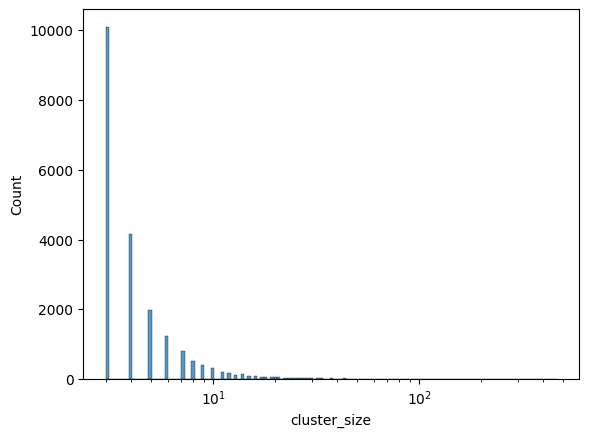

In [21]:
sns.histplot(df[['cluster_id', 'cluster_size']].drop_duplicates().cluster_size, log_scale=True)


In [22]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_volcano(df, pval_threshold=0.05, fold_threshold=0, sample_name="", ax=None):
    df = df.copy()
    df['log10_pval'] = -np.log10(df['enrichment_pvalue_zbinom'] + 1e-10)
    df['significant'] = (df['enrichment_fdr_zbinom'] < pval_threshold) & (df['log_fold_change'] > fold_threshold)

    # Определение цветов
    main_color = '#2171b5'   # синий для значимых
    base_color = '#ffffcc'   # жёлтый для остальных

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Рисуем все точки (не vdjdb)
    sns.scatterplot(
        data=df[~df['vdjdb']],
        x='log_fold_change',
        y='log10_pval',
        hue='significant',
        palette={True: main_color, False: base_color},
        edgecolor='black',
        linewidth=0.3,
        ax=ax,
        # s=70,
        alpha=0.85,
    )

    # Поверх них рисуем vdjdb точки красными квадратами
    sns.scatterplot(
        data=df[df['vdjdb']],
        x='log_fold_change',
        y='log10_pval',
        marker='s',
        color='red',
        edgecolor='black',
        linewidth=0.4,
        ax=ax,
        # s=70,
        alpha=1.0,
        label='as_pattern'
    )

    # Линии порогов
    bonferroni_thresh = max(df[df['enrichment_fdr_zbinom'] < pval_threshold]['enrichment_pvalue_zbinom'], default=1.0)
    log10_bonferroni = -np.log10(bonferroni_thresh)
    ax.axvline(fold_threshold, ls='--', color='black')
    ax.axhline(-np.log10(pval_threshold), ls='--', color='black')
    ax.axhline(log10_bonferroni, ls=':', color='blue')

    # Подписи
    num_significant = df['significant'].sum()
    ax.set_xlabel('log2(Fold Enrichment)')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title(f'{sample_name}: # clusters (fdr < {pval_threshold}): {num_significant}')
    ax.legend()


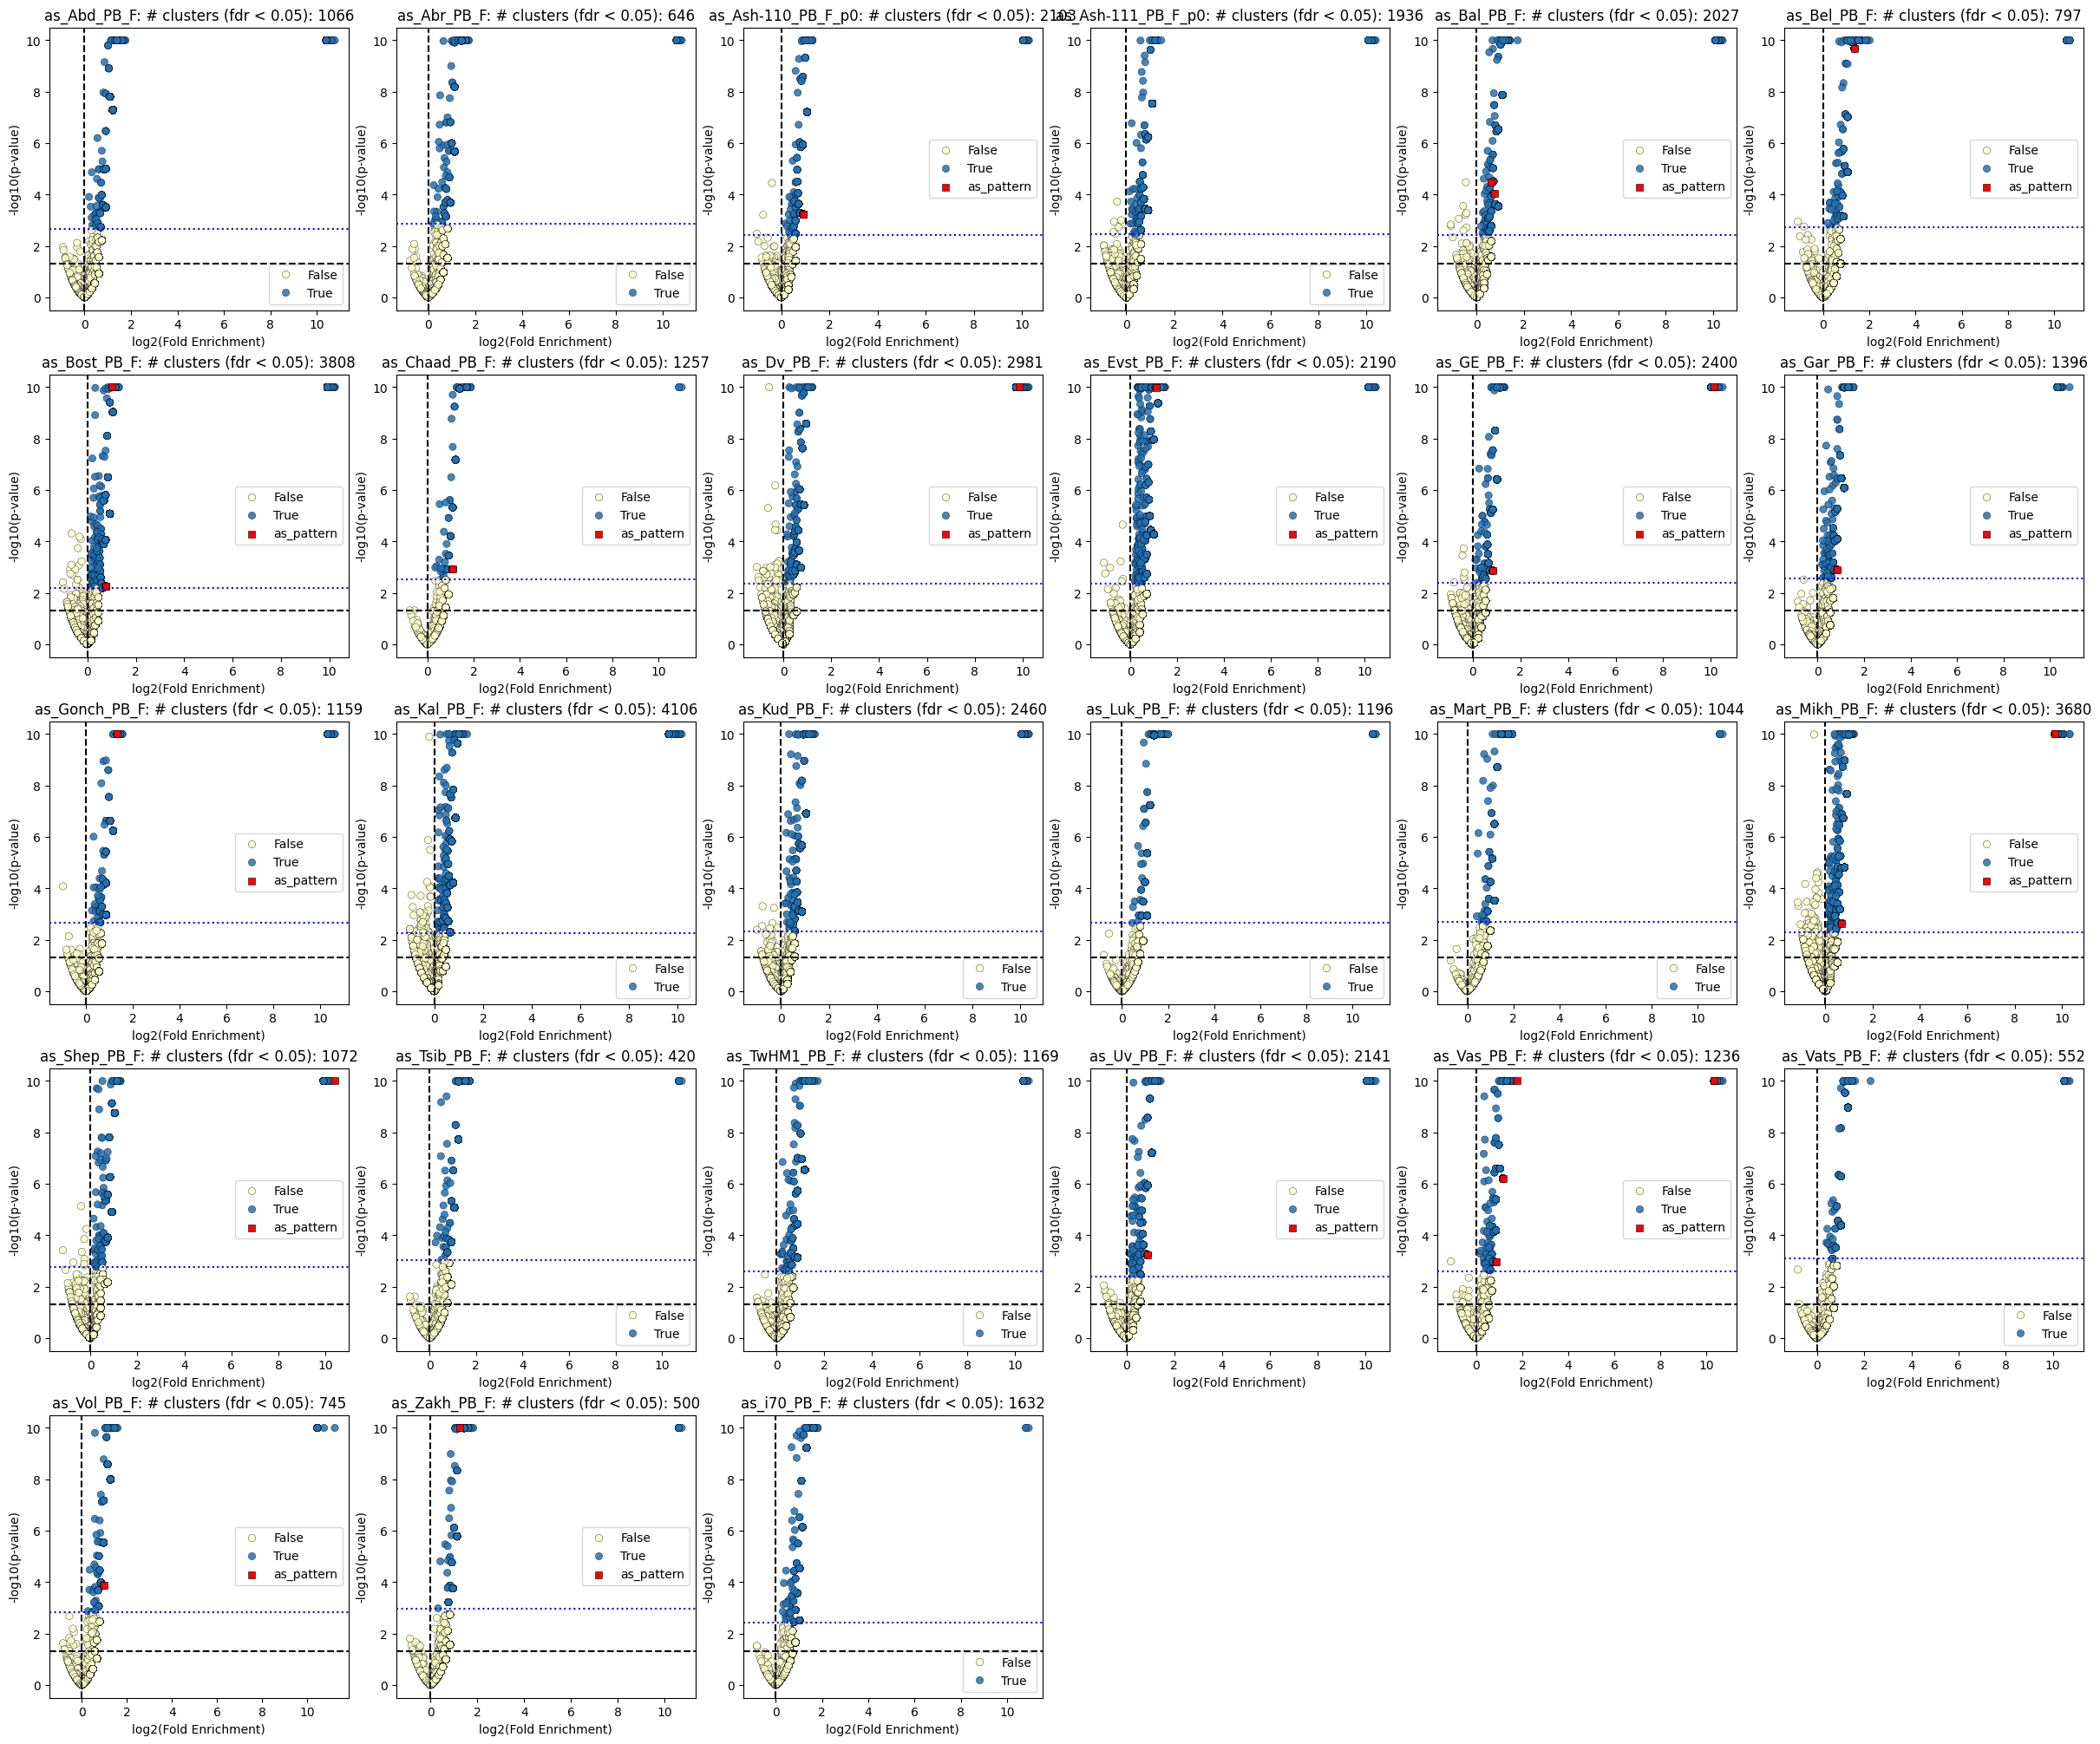

In [23]:
import matplotlib.pyplot as plt

ncols = 6
nrows = 5
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 4), constrained_layout=True)

for i, s in enumerate(samples):
    row, col = divmod(i, ncols)
    ax = axes[row, col]
    s_res = sample_to_data[s]
    plot_volcano(s_res[0], ax=ax, fold_threshold=0, sample_name=s)

# Удалим лишние пустые сабплоты (если samples < 27)
for j in range(len(samples), ncols * nrows):
    fig.delaxes(axes[j // ncols, j % ncols])
plt.savefig('as_volcanos.png', dpi=300)
plt.show()

In [24]:
all_info = []
for s in samples:
    s_res = sample_to_data[s][0]
    res_df = s_res[['cluster_id', 'vdjdb', 'enrichment_fdr_zbinom', 'log_fold_change']]
    res_df = res_df[(res_df.enrichment_fdr_zbinom < 0.05) & (res_df.log_fold_change > 0)]
    res_df['sample'] = s
    all_info.append(res_df)

In [25]:
joint = pd.concat(all_info)

In [26]:
joint

,cluster_id,vdjdb,enrichment_fdr_zbinom,log_fold_change,sample
3,3,False,3.530990e-04,0.923553,as_Abd_PB_F
8,8,False,0.000000e+00,10.400674,as_Abd_PB_F
10,10,False,8.691702e-09,1.020463,as_Abd_PB_F
11,11,False,0.000000e+00,10.400674,as_Abd_PB_F
12,12,False,1.956989e-06,1.224583,as_Abd_PB_F
...,...,...,...,...,...
21093,21093,False,4.080406e-02,1.027576,as_i70_PB_F
21105,21105,False,4.080406e-02,1.027576,as_i70_PB_F
21108,21108,False,4.080406e-02,1.027576,as_i70_PB_F
21109,21109,False,4.080406e-02,1.027576,as_i70_PB_F


In [27]:
joint = joint.rename(columns={'log_fold_change': 'fold_enrichment', 'enrichment_fdr_zbinom': 'pvalue'})

In [28]:
joint[joint.vdjdb].sort_values(by='sample')

,cluster_id,vdjdb,pvalue,fold_enrichment,sample
1585,1585,True,7.538228e-03,0.891663,as_Ash-110_PB_F_p0
4741,4741,True,7.538228e-03,0.891663,as_Ash-110_PB_F_p0
483,483,True,3.853976e-03,0.751255,as_Bal_PB_F
663,663,True,1.572316e-03,0.626316,as_Bal_PB_F
964,964,True,6.264697e-09,1.358001,as_Bel_PB_F
425,425,True,4.215758e-12,0.996437,as_Bost_PB_F
5196,5196,True,4.560265e-02,0.753399,as_Bost_PB_F
5474,5474,True,4.560265e-02,0.753399,as_Bost_PB_F
11519,11519,True,2.057764e-02,1.093133,as_Chaad_PB_F
5294,5294,True,0.000000e+00,9.856962,as_Dv_PB_F


In [29]:
joint[joint['sample'] == 'as_Abd_PB_F'].cluster_id

3            3
8            8
10          10
11          11
12          12
         ...  
22701    22701
22752    22752
22758    22758
22826    22826
22827    22827
Name: cluster_id, Length: 1066, dtype: int64

In [30]:
all_clonotypes_enriched = []
for patient in samples:
    t = get_clonotypes(patient).drop(columns=['enrichment_pvalue_zbinom'])
    # t = t[t.source == 'sample']
    t = t[t.cluster_id.isin(joint[joint['sample'] == patient].cluster_id)]
    t['cluster_id'] = patient + '_c' + t.cluster_id.astype(str)
    t['sample_name'] = patient
    all_clonotypes_enriched.append(t)

In [31]:
data = pd.concat(all_clonotypes_enriched)#.drop(columns=['source'])
data

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name
0,s_11,as_Abd_PB_F_c3,CASSLRGAYEQYF,TRBV28*01,TRBJ2-7*01,sample,as_Abd_PB_F
1,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F
2,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F
3,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F
4,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F
...,...,...,...,...,...,...,...
7869,b_856969,as_i70_PB_F_c3679,CSPGVSDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F
7870,b_857032,as_i70_PB_F_c3679,CSVGETDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F
7871,b_857090,as_i70_PB_F_c291,CSVELGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F
7872,b_857119,as_i70_PB_F_c291,CSVETGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F


In [32]:
data['vdjdb'] = data.cdr3aa_beta.apply(lambda x: has_vdjdb_match(x) > 0)

In [33]:
data[data.vdjdb][['sample_name']].drop_duplicates()

,sample_name
403,as_Ash-110_PB_F_p0
162,as_Bal_PB_F
130,as_Bel_PB_F
187,as_Bost_PB_F
3285,as_Chaad_PB_F
1632,as_Dv_PB_F
30,as_Evst_PB_F
25,as_GE_PB_F
872,as_Gar_PB_F
187,as_Gonch_PB_F


In [34]:
found_clonotypes = [ClonotypeAA(cdr3aa=x) for x in data.cdr3aa_beta]
dataset = ClonotypeDataset(found_clonotypes)

In [35]:
import networkx as nx
from collections import defaultdict

In [36]:
df = data

In [37]:
# 1. Построить отображение: cdr3aa → множество cluster_id
cdr3_to_clusters = defaultdict(set)
for _, row in df.iterrows():
    cdr3_to_clusters[row['cdr3aa_beta']].add(row['cluster_id'])

# 2. Построить граф кластеров, связанных общими сиквенсами
G = nx.Graph()
G.add_nodes_from(df['cluster_id'].unique())

for clusters in cdr3_to_clusters.values():
    clusters = list(clusters)
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            G.add_edge(clusters[i], clusters[j])

# 3. Компоненты связности → объединённые кластеры
cluster_mapping = {}
for new_id, component in enumerate(nx.connected_components(G)):
    for cluster_id in component:
        cluster_mapping[cluster_id] = new_id

# 4. Применить маппинг
df['merged_cluster_id'] = df['cluster_id'].map(cluster_mapping)

In [38]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id
0,s_11,as_Abd_PB_F_c3,CASSLRGAYEQYF,TRBV28*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0
1,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,1
2,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,2
3,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,3
4,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,4
...,...,...,...,...,...,...,...,...,...
7869,b_856969,as_i70_PB_F_c3679,CSPGVSDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,1488
7870,b_857032,as_i70_PB_F_c3679,CSVGETDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,1488
7871,b_857090,as_i70_PB_F_c291,CSVELGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,20136
7872,b_857119,as_i70_PB_F_c291,CSVETGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,20136


In [39]:
df['as_pattern'] = df.cdr3aa_beta.apply(lambda x: has_vdjdb_match(x) > 0)

In [40]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern
0,s_11,as_Abd_PB_F_c3,CASSLRGAYEQYF,TRBV28*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0,False
1,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,1,False
2,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,2,False
3,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,3,False
4,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,4,False
...,...,...,...,...,...,...,...,...,...,...
7869,b_856969,as_i70_PB_F_c3679,CSPGVSDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,1488,False
7870,b_857032,as_i70_PB_F_c3679,CSVGETDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,1488,False
7871,b_857090,as_i70_PB_F_c291,CSVELGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,20136,False
7872,b_857119,as_i70_PB_F_c291,CSVETGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,20136,False


In [41]:
df.cluster_id.value_counts()

cluster_id
as_Bost_PB_F_c125          677
as_GE_PB_F_c139            622
as_Evst_PB_F_c13           600
as_Ash-111_PB_F_p0_c379    587
as_Uv_PB_F_c73             564
                          ... 
as_i70_PB_F_c3581            3
as_i70_PB_F_c3582            3
as_i70_PB_F_c3589            3
as_i70_PB_F_c18778           3
as_i70_PB_F_c3592            3
Name: count, Length: 45719, dtype: int64

In [42]:
df.merged_cluster_id.value_counts()

merged_cluster_id
134      8449
27       5260
132      4144
26       3856
1447     3192
         ... 
24439       3
24441       3
24443       3
24444       3
24446       3
Name: count, Length: 24489, dtype: int64

In [43]:
df.groupby("merged_cluster_id").nunique()[["sample_name", 'as_pattern']]
# test['as_pattern'].value_counts()

,sample_name,as_pattern
merged_cluster_id,,
0,24,1
1,2,1
2,11,1
3,1,1
4,1,1
...,...,...
24484,1,1
24485,1,1
24486,1,1


In [44]:
source_counts = df.pivot_table(index='merged_cluster_id', columns='source', 
                               values='clone_id', aggfunc='count', fill_value=0).reset_index()
source_counts

source,merged_cluster_id,background,sample
0,0,478,564
1,1,3,5
2,2,41,67
3,3,0,3
4,4,1,2
...,...,...,...
24484,24484,2,1
24485,24485,4,2
24486,24486,2,1
24487,24487,2,1


In [45]:
df.groupby('merged_cluster_id').agg({
    'sample_name': 'nunique',          # количество уникальных значений
    'as_pattern': 'any'               # хотя бы одно True
})

,sample_name,as_pattern
merged_cluster_id,,
0,24,False
1,2,False
2,11,False
3,1,False
4,1,False
...,...,...
24484,1,False
24485,1,False
24486,1,False


In [46]:
from mir.basic.pgen import OlgaModel

In [47]:
olga = OlgaModel()

In [48]:
olga.compute_pgen_cdr3aa('CASSPPSGSYEQYF')

2.0855611266511384e-07

In [49]:
df['pgen'] = df.cdr3aa_beta.apply(olga.compute_pgen_cdr3aa)

In [50]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
0,s_11,as_Abd_PB_F_c3,CASSLRGAYEQYF,TRBV28*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0,False,1.632073e-06
1,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,1,False,2.085561e-07
2,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,2,False,1.071792e-06
3,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,3,False,9.615423e-09
4,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,4,False,4.903500e-08
...,...,...,...,...,...,...,...,...,...,...,...
7869,b_856969,as_i70_PB_F_c3679,CSPGVSDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,1488,False,1.044155e-09
7870,b_857032,as_i70_PB_F_c3679,CSVGETDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,1488,False,1.416701e-08
7871,b_857090,as_i70_PB_F_c291,CSVELGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,20136,False,1.065633e-08
7872,b_857119,as_i70_PB_F_c291,CSVETGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,20136,False,3.969749e-08


In [51]:
# Считаем общий размер кластера
cluster_sizes = df.groupby("merged_cluster_id").size().reset_index(name="cluster_size")

# Считаем количество пациентов и наличие паттерна
n_patients = df.groupby('merged_cluster_id').agg({
    'sample_name': 'nunique',
    'as_pattern': 'any', 
    # 'pgen': 'mean'
}).reset_index().rename(columns={'sample_name': "n_patients"})

# Считаем количество элементов из каждого источника (source)
source_counts = df.pivot_table(index='merged_cluster_id', columns='source', 
                               values='clone_id', aggfunc='count', fill_value=0).reset_index()

# Объединяем таблицы
summary = cluster_sizes.merge(n_patients, on="merged_cluster_id")
summary = summary.merge(source_counts, on="merged_cluster_id")

# Считаем доли элементов из каждого источника
summary['sample_fraction'] = summary.get('sample', 0) / summary['cluster_size']
summary['background_fraction'] = summary.get('background', 0) / summary['cluster_size']

# Сортировка
summary = summary.sort_values(by=["n_patients", "cluster_size"], ascending=False)


In [52]:
summary

,merged_cluster_id,cluster_size,n_patients,as_pattern,background,sample,sample_fraction,background_fraction
27,27,5260,27,False,3095,2165,0.411597,0.588403
26,26,3856,27,False,2247,1609,0.417272,0.582728
5,5,2520,27,False,1286,1234,0.489683,0.510317
126,126,2413,27,False,1226,1187,0.491919,0.508081
166,166,1525,27,False,825,700,0.459016,0.540984
...,...,...,...,...,...,...,...,...
24482,24482,3,1,False,2,1,0.333333,0.666667
24484,24484,3,1,False,2,1,0.333333,0.666667
24486,24486,3,1,False,2,1,0.333333,0.666667
24487,24487,3,1,False,2,1,0.333333,0.666667


In [53]:
#summary[summary.n_patients > 3].sort_values(by=['pgen',  'sample_fraction', 'n_patients'], ascending=True).head(50).reset_index(drop=True)

In [54]:
summary.sort_values(by='cluster_size', ascending=False).head(10)

,merged_cluster_id,cluster_size,n_patients,as_pattern,background,sample,sample_fraction,background_fraction
134,134,8449,16,False,6402,2047,0.242277,0.757723
27,27,5260,27,False,3095,2165,0.411597,0.588403
132,132,4144,17,False,2709,1435,0.346284,0.653716
26,26,3856,27,False,2247,1609,0.417272,0.582728
1447,1447,3192,18,False,2180,1012,0.317043,0.682957
33,33,3012,25,False,1795,1217,0.404050,0.595950
5,5,2520,27,False,1286,1234,0.489683,0.510317
1990,1990,2430,15,False,1564,866,0.356379,0.643621
126,126,2413,27,False,1226,1187,0.491919,0.508081
114,114,2326,26,False,1367,959,0.412296,0.587704


In [55]:
summary[summary.as_pattern]

,merged_cluster_id,cluster_size,n_patients,as_pattern,background,sample,sample_fraction,background_fraction
4503,4503,75,12,True,16,59,0.786667,0.213333
2212,2212,20,5,True,9,11,0.550000,0.450000
4536,4536,21,2,True,10,11,0.523810,0.476190
8948,8948,7,2,True,4,3,0.428571,0.571429
12523,12523,7,2,True,0,7,1.000000,0.000000
19200,19200,4,1,True,1,3,0.750000,0.250000
1722,1722,3,1,True,1,2,0.666667,0.333333
19362,19362,3,1,True,0,3,1.000000,0.000000


In [56]:
import logomaker

In [57]:
def plot_logo(clonotypes):
    mat_df = logomaker.alignment_to_matrix(clonotypes)
    logomaker.Logo(mat_df, color_scheme='skylign_protein', ax=None)

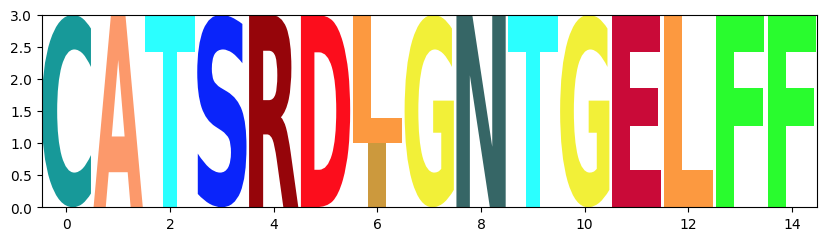

In [58]:
mat_df = logomaker.alignment_to_matrix(df[df.merged_cluster_id == 4514].cdr3aa_beta)
logomaker.Logo(mat_df, color_scheme='skylign_protein', ax=None)
# df[df.merged_cluster_id == 2309]

In [59]:
from mir.common.parser import *
from mir.common.repertoire import Repertoire
from mir.common.repertoire_dataset import RepertoireDataset
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.basic.segment_usage import *
from mir.basic.sampling import RepertoireSampling
from mir.biomarkers.fisher_biomarkers_detector import FisherBiomarkersDetector
from mir.comparative.pair_matcher import PairMatcher
import time
from pympler.asizeof import asizeof

/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [60]:
metadata = metadata.reset_index(drop=True)

In [61]:
t0 = time.time()
dataset = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=metadata,
                                 threads=16,
                                 paths=[f'/projects/immunestatus/rheum/airr_format/{r}.tsv' for r in samples], 
                                 gene='TRB')
print(time.time() - t0)

loading Repertoire objects: 100%|██████████| 27/27 [00:42<00:00,  1.57s/it]

42.77044463157654


In [62]:
dataset.pair_matcher = PairMatcher(clonotype_representation_method='cdr3aa,vj',
                                   clonotype_comparison_method='full',)

In [63]:
dataset.mismatch_max = 0

In [64]:
from mir.comparative.pair_matcher import ClonotypeRepresentation

In [65]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
0,s_11,as_Abd_PB_F_c3,CASSLRGAYEQYF,TRBV28*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0,False,1.632073e-06
1,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,1,False,2.085561e-07
2,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,2,False,1.071792e-06
3,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,3,False,9.615423e-09
4,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,4,False,4.903500e-08
...,...,...,...,...,...,...,...,...,...,...,...
7869,b_856969,as_i70_PB_F_c3679,CSPGVSDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,1488,False,1.044155e-09
7870,b_857032,as_i70_PB_F_c3679,CSVGETDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,1488,False,1.416701e-08
7871,b_857090,as_i70_PB_F_c291,CSVELGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,20136,False,1.065633e-08
7872,b_857119,as_i70_PB_F_c291,CSVETGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,20136,False,3.969749e-08


In [66]:
public_clonotypes = df.apply(lambda x: ClonotypeRepresentation(cdr3aa=x.cdr3aa_beta, v=x.v_beta, j=x.j_beta), axis=1)

In [67]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
0,s_11,as_Abd_PB_F_c3,CASSLRGAYEQYF,TRBV28*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0,False,1.632073e-06
1,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,1,False,2.085561e-07
2,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,2,False,1.071792e-06
3,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,3,False,9.615423e-09
4,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,4,False,4.903500e-08
...,...,...,...,...,...,...,...,...,...,...,...
7869,b_856969,as_i70_PB_F_c3679,CSPGVSDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,1488,False,1.044155e-09
7870,b_857032,as_i70_PB_F_c3679,CSVGETDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,1488,False,1.416701e-08
7871,b_857090,as_i70_PB_F_c291,CSVELGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,20136,False,1.065633e-08
7872,b_857119,as_i70_PB_F_c291,CSVETGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,20136,False,3.969749e-08


In [68]:
public_clonotypes= public_clonotypes.reset_index(drop=True)

In [69]:
public_clonotypes = list(public_clonotypes)

In [70]:
public_clonotypes[10]

ClonotypeRepresentation(cdr3aa='CASSPDRGRTGELFF', v='TRBV12-3*01', j='TRBJ2-2*01', cdr3nt=None)

In [71]:
public_clono_set = set(public_clonotypes)

In [72]:
len(public_clono_set)

167556

In [73]:
list(public_clono_set)[10]

ClonotypeRepresentation(cdr3aa='CAISEATETQYF', v='TRBV10-3*01', j='TRBJ2-5*01', cdr3nt=None)

In [74]:
ClonotypeRepresentation(cdr3aa = dataset[0][0].cdr3aa, v=dataset[0][0].v.id, j = dataset[0][0].j.id)

ClonotypeRepresentation(cdr3aa='CSASSETGELFF', v='TRBV20-1*01', j='TRBJ2-2*01', cdr3nt=None)

In [75]:
ClonotypeRepresentation(cdr3aa='CSAKDRGRVTEAFF', v='TRBV20-1*01', j='TRBJ1-1*01') in public_clonotypes

True

In [76]:
clonotype_idx_to_patients = defaultdict(set)
for patient in dataset:
    patient_clono_repr_set = set([ClonotypeRepresentation(cdr3aa=x.cdr3aa, v=x.v.id, j=x.j.id) for x in patient.clonotypes])
    for i, clonotype_repr in enumerate(public_clonotypes):
        if clonotype_repr in patient_clono_repr_set:
            clonotype_idx_to_patients[i].add(patient)

In [77]:
metadata_h =metadata_h.reset_index(drop=True)

In [78]:
metadata_h

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN
2,p144852,hd,pos,ch45-2,PBMC,after G-CSFstim,p144852,NaN
3,p1004,hd,pos,child_Leu,PBMC,after G-CSFstim,p1004,NaN
4,p112635,hd,pos,ch45-2,PBMC,after G-CSFstim,p112635,NaN
5,p434,hd,neg,child_Leu,PBMC,after G-CSFstim,p434,NaN
6,p556,hd,neg,child_Leu,PBMC,after G-CSFstim,p556,NaN
7,p744,hd,neg,child_Leu,PBMC,after G-CSFstim,p744,NaN
8,p754,hd,neg,child_Leu,PBMC,after G-CSFstim,p754,NaN
9,p1005,hd,neg,child_Leu,PBMC,after G-CSFstim,p1005,NaN


In [79]:
#metadata_h = metadata_h[metadata_h.b27 == 'pos'].reset_index(drop=True)

In [80]:
t0 = time.time()
dataset_h = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=metadata_h,
                                 threads=16,
                                 paths=[f'/projects/immunestatus/rheum/airr_format/{r}.tsv' for r in metadata_h.sample_name], 
                                 gene='TRB')
print(time.time() - t0)

loading Repertoire objects: 100%|██████████| 33/33 [01:01<00:00,  1.86s/it]


62.437724590301514


In [81]:
clonotype_idx_to_patients_h = defaultdict(set)
for patient in dataset_h:
    patient_clono_repr_set = set([ClonotypeRepresentation(cdr3aa=x.cdr3aa, v=x.v.id, j=x.j.id) for x in patient.clonotypes])
    for i, clonotype_repr in enumerate(public_clonotypes):
        if clonotype_repr in patient_clono_repr_set:
            clonotype_idx_to_patients_h[i].add(patient)

In [82]:
df = df.reset_index(drop=True)

In [83]:
def get_cluster_usage(cluster_idx):
    all_patients = set()
    for clono_idx in df[df.merged_cluster_id == cluster_idx].index:
        all_patients = all_patients.union(clonotype_idx_to_patients[clono_idx])
        # print(clono_idx, [x.metadata.sample_name for x in clonotype_idx_to_patients[clono_idx]])
    return len(all_patients)

In [84]:
def get_cluster_usage_h(cluster_idx, print_info=False):
    all_patients = set()
    for clono_idx in df[df.merged_cluster_id == cluster_idx].index:
        all_patients = all_patients.union(clonotype_idx_to_patients_h[clono_idx])
        if print_info:
            print(clono_idx, [x.metadata.sample_name for x in clonotype_idx_to_patients_h[clono_idx]])
    return len(all_patients)

In [85]:
get_cluster_usage_h(2309, print_info=True)

13486 ['p744']
13507 ['hd_OB_PB_F']
19863 ['p1694', 'p2301', 'hd_Sass_PB_F']
74552 ['p744']
76567 []
80245 []
89654 ['p1694', 'p2301', 'hd_Sass_PB_F']


5

In [86]:
summary['as_usage'] = summary.merged_cluster_id.apply(get_cluster_usage)

In [87]:
summary['h_usage'] = summary.merged_cluster_id.apply(get_cluster_usage_h)

In [88]:
summary[summary.n_patients > 3].sort_values(by=['sample_fraction', 'n_patients'], ascending=False).head(60).reset_index(drop=True)

,merged_cluster_id,cluster_size,n_patients,as_pattern,background,sample,sample_fraction,background_fraction,as_usage,h_usage
0,12,25,5,False,0,25,1.000000,0.000000,11,12
1,7575,19,4,False,0,19,1.000000,0.000000,9,17
2,2972,13,4,False,0,13,1.000000,0.000000,12,18
3,6064,12,4,False,0,12,1.000000,0.000000,10,11
4,15770,14,4,False,1,13,0.928571,0.071429,7,6
5,137,83,8,False,6,77,0.927711,0.072289,13,21
6,9516,20,4,False,2,18,0.900000,0.100000,10,6
7,2768,19,6,False,2,17,0.894737,0.105263,16,18
8,4689,18,4,False,2,16,0.888889,0.111111,8,9
9,6287,16,4,False,2,14,0.875000,0.125000,12,17


In [89]:
from scipy.stats import fisher_exact

In [90]:
total_as = 27
total_h = 33

# Результаты
p_values = []

# Пробегаем по строкам таблицы
for _, row in summary.iterrows():
    as_used = row["as_usage"]
    h_used = row["h_usage"]
    
    as_not_used = total_as - as_used
    h_not_used = total_h - h_used
    
    # Таблица сопряженности
    contingency = [[as_used, as_not_used],
                   [h_used, h_not_used]]
    
    # Односторонний тест: альтернативная гипотеза — "as > h"
    _, p_value = fisher_exact(contingency)#, alternative='greater')
    p_values.append(p_value)

# Добавим столбец с p-value
summary["fisher_p"] = p_values

In [91]:
summary

,merged_cluster_id,cluster_size,n_patients,as_pattern,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p
27,27,5260,27,False,3095,2165,0.411597,0.588403,27,33,1.000000
26,26,3856,27,False,2247,1609,0.417272,0.582728,27,33,1.000000
5,5,2520,27,False,1286,1234,0.489683,0.510317,27,33,1.000000
126,126,2413,27,False,1226,1187,0.491919,0.508081,27,33,1.000000
166,166,1525,27,False,825,700,0.459016,0.540984,27,33,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
24482,24482,3,1,False,2,1,0.333333,0.666667,1,5,0.209248
24484,24484,3,1,False,2,1,0.333333,0.666667,2,10,0.048981
24486,24486,3,1,False,2,1,0.333333,0.666667,1,2,1.000000
24487,24487,3,1,False,2,1,0.333333,0.666667,2,4,0.681231


In [92]:
summary[summary.as_pattern]

,merged_cluster_id,cluster_size,n_patients,as_pattern,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p
4503,4503,75,12,True,16,59,0.786667,0.213333,16,8,0.008324
2212,2212,20,5,True,9,11,0.550000,0.450000,15,21,0.601120
4536,4536,21,2,True,10,11,0.523810,0.476190,12,16,0.799425
8948,8948,7,2,True,4,3,0.428571,0.571429,8,12,0.783610
12523,12523,7,2,True,0,7,1.000000,0.000000,5,0,0.014782
19200,19200,4,1,True,1,3,0.750000,0.250000,1,2,1.000000
1722,1722,3,1,True,1,2,0.666667,0.333333,4,3,0.690086
19362,19362,3,1,True,0,3,1.000000,0.000000,4,9,0.347962


In [93]:
summary[summary.fisher_p < 0.05]

,merged_cluster_id,cluster_size,n_patients,as_pattern,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p
731,731,123,15,False,64,59,0.479675,0.520325,23,33,0.035990
2285,2285,121,12,False,46,75,0.619835,0.380165,18,30,0.025764
4503,4503,75,12,True,16,59,0.786667,0.213333,16,8,0.008324
979,979,133,11,False,49,84,0.631579,0.368421,20,32,0.017748
1138,1138,118,10,False,55,63,0.533898,0.466102,23,33,0.035990
...,...,...,...,...,...,...,...,...,...,...,...
22754,22754,3,1,False,0,3,1.000000,0.000000,4,0,0.035990
23820,23820,3,1,False,2,1,0.333333,0.666667,1,9,0.017203
23917,23917,3,1,False,2,1,0.333333,0.666667,1,8,0.033240
24315,24315,3,1,False,2,1,0.333333,0.666667,1,8,0.033240


In [94]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import KDTree

def plot_volcano(summary,
                 pval_col="fisher_p",
                 as_col="as_usage",
                 h_col="h_usage",
                 pattern_col="as_pattern",
                 label_col="merged_cluster_id",
                 pval_thresh=0.05,
                 label_log2_thresh=1,
                 label_pval_thresh=0.01,
                 merge_distance=0.2):
    """
    Volcano plot с выделением значимых точек, паттернов и агрегацией подписей для близких точек.

    Parameters:
        summary (pd.DataFrame): таблица с колонками `as_usage`, `h_usage`, `fisher_p`, `as_pattern`, `merged_cluster_id`.
        pval_col (str): колонка с p-value.
        as_col (str): колонка с количеством в AS группе.
        h_col (str): колонка с количеством в healthy группе.
        pattern_col (str): булева колонка, выделяющая особый кластер.
        label_col (str): колонка, которую подписывать.
        pval_thresh (float): порог значимости для цвета.
        label_log2_thresh (float): log2 OR выше которого подписываем.
        label_pval_thresh (float): p-value ниже которого подписываем.
        merge_distance (float): расстояние на графике, на котором подписи будут объединяться.
    """
    pseudo = 0.5
    summary = summary.copy()

    summary["log2_or"] = np.log2((summary[as_col] + pseudo) / (summary[h_col] + pseudo))
    summary["neg_log10_p"] = -np.log10(summary[pval_col])

    def categorize(row):
        if row[pattern_col]:
            return "pattern"
        elif row[pval_col] < pval_thresh:
            return "significant"
        else:
            return "nonsignificant"

    summary["volcano_category"] = summary.apply(categorize, axis=1)
    palette = {"nonsignificant": "gray", "significant": "red", "pattern": "blue"}

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=summary,
        x="log2_or",
        y="neg_log10_p",
        hue="volcano_category",
        palette=palette,
        alpha=0.8
    )

    # Подготовка подписей
    labeled = summary[(summary["log2_or"] > label_log2_thresh) &
                      (summary[pval_col] < label_pval_thresh)].copy()

    if not labeled.empty:
        points = np.column_stack((labeled["log2_or"], labeled["neg_log10_p"]))
        tree = KDTree(points)
        visited = set()
        for i, point in enumerate(points):
            if i in visited:
                continue
            idxs = tree.query_ball_point(point, r=merge_distance)
            visited.update(idxs)
            cluster_labels = labeled.iloc[idxs][label_col].astype(str).tolist()
            x, y = point
            plt.text(x, y, ",".join(cluster_labels), fontsize=9, ha='left', va='bottom')

    plt.axhline(-np.log10(pval_thresh), linestyle="--", color="black", label=f"p = {pval_thresh}")
    plt.axvline(0, linestyle="--", color="gray")
    plt.xlabel("log2(AS usage / Healthy usage)")
    plt.ylabel("-log10(p-value)")
    plt.title("Volcano Plot (Fisher's exact test)")
    plt.legend(title="Category")
    plt.tight_layout()
    plt.show()


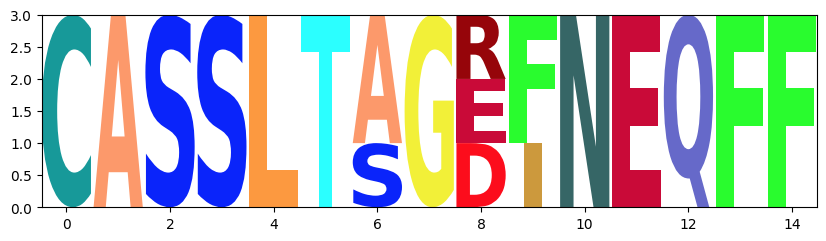

In [95]:
plot_logo(df[df.merged_cluster_id == 3655].cdr3aa_beta)

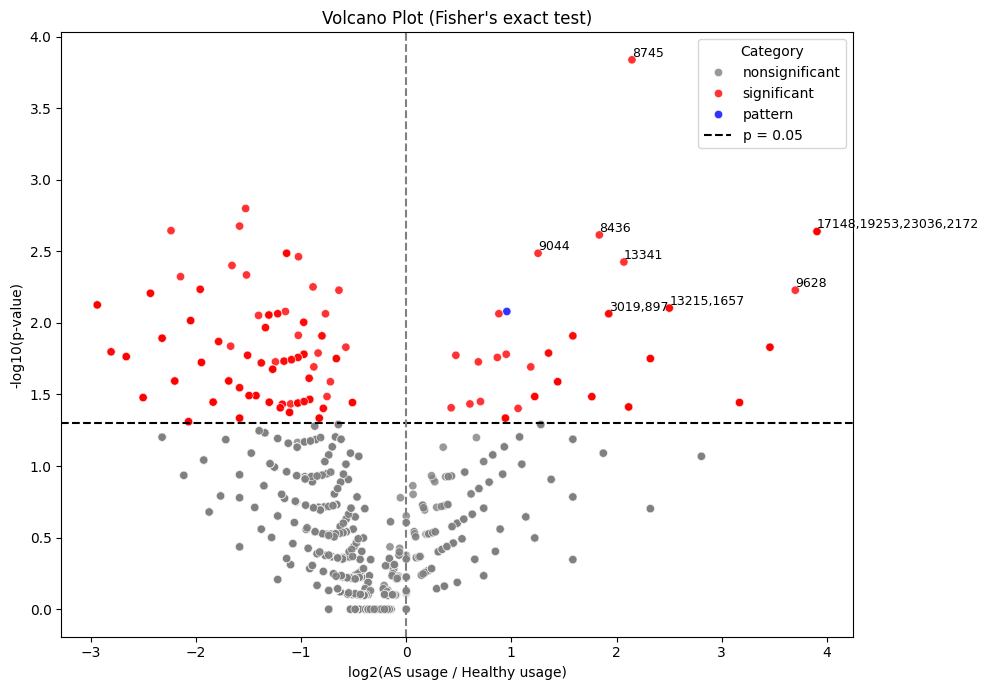

In [96]:
plot_volcano(summary)


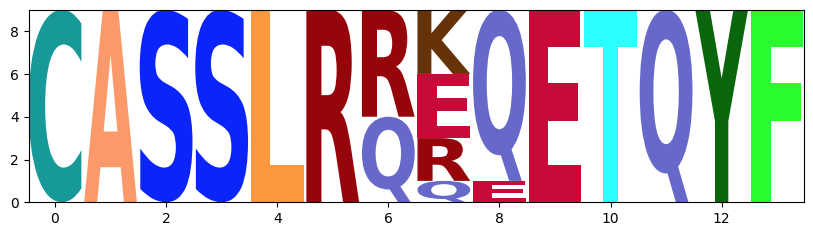

In [128]:
plot_logo(df[df.merged_cluster_id == 8745].cdr3aa_beta)

In [98]:
summary

,merged_cluster_id,cluster_size,n_patients,as_pattern,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p
27,27,5260,27,False,3095,2165,0.411597,0.588403,27,33,1.000000
26,26,3856,27,False,2247,1609,0.417272,0.582728,27,33,1.000000
5,5,2520,27,False,1286,1234,0.489683,0.510317,27,33,1.000000
126,126,2413,27,False,1226,1187,0.491919,0.508081,27,33,1.000000
166,166,1525,27,False,825,700,0.459016,0.540984,27,33,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
24482,24482,3,1,False,2,1,0.333333,0.666667,1,5,0.209248
24484,24484,3,1,False,2,1,0.333333,0.666667,2,10,0.048981
24486,24486,3,1,False,2,1,0.333333,0.666667,1,2,1.000000
24487,24487,3,1,False,2,1,0.333333,0.666667,2,4,0.681231


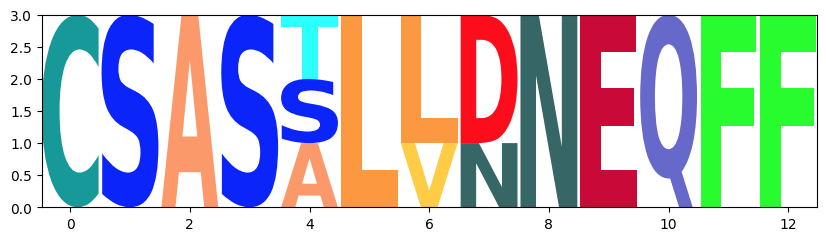

In [99]:
plot_logo(df[df.merged_cluster_id == 2856].cdr3aa_beta)

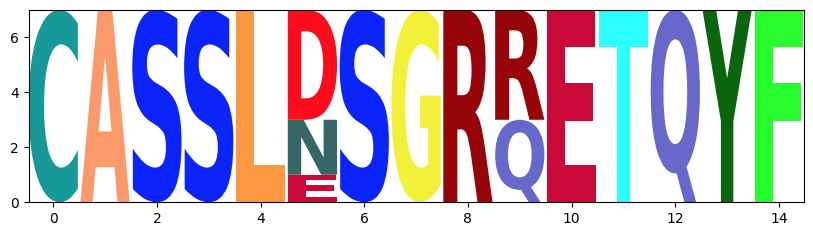

In [100]:
plot_logo(df[df.merged_cluster_id == 2309].cdr3aa_beta)

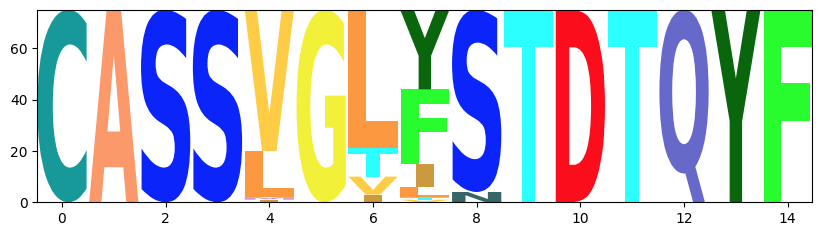

In [101]:
plot_logo(df[df.merged_cluster_id == 4503].cdr3aa_beta)

In [102]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
0,s_11,as_Abd_PB_F_c3,CASSLRGAYEQYF,TRBV28*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0,False,1.632073e-06
1,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,1,False,2.085561e-07
2,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,2,False,1.071792e-06
3,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,3,False,9.615423e-09
4,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,4,False,4.903500e-08
...,...,...,...,...,...,...,...,...,...,...,...
275877,b_856969,as_i70_PB_F_c3679,CSPGVSDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,1488,False,1.044155e-09
275878,b_857032,as_i70_PB_F_c3679,CSVGETDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,1488,False,1.416701e-08
275879,b_857090,as_i70_PB_F_c291,CSVELGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,20136,False,1.065633e-08
275880,b_857119,as_i70_PB_F_c291,CSVETGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,20136,False,3.969749e-08


In [114]:
pgen_df = df.groupby('merged_cluster_id').agg({
    'pgen': 'mean'
}).reset_index()
pgen_df

,merged_cluster_id,pgen
0,0,7.266630e-07
1,1,1.565000e-07
2,2,6.259052e-07
3,3,8.828989e-09
4,4,3.806336e-08
...,...,...
24484,24484,1.172537e-07
24485,24485,1.952171e-08
24486,24486,6.422961e-10
24487,24487,4.641977e-10


In [115]:
pgen_df['log_pgen'] = np.log10(pgen_df.pgen)

In [116]:
summary = summary.merge(pgen_df[['merged_cluster_id', 'log_pgen']])
summary

,merged_cluster_id,cluster_size,n_patients,as_pattern,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p,patient_fc,log_patient_fc,log_cluster_size,log_pgen
0,27,5260,27,False,3095,2165,0.411597,0.588403,27,33,1.000000,1.000000,0.000000,3.720986,-6.321148
1,26,3856,27,False,2247,1609,0.417272,0.582728,27,33,1.000000,1.000000,0.000000,3.586137,-6.785170
2,5,2520,27,False,1286,1234,0.489683,0.510317,27,33,1.000000,1.000000,0.000000,3.401401,-6.401062
3,126,2413,27,False,1226,1187,0.491919,0.508081,27,33,1.000000,1.000000,0.000000,3.382557,-6.628348
4,166,1525,27,False,825,700,0.459016,0.540984,27,33,1.000000,1.000000,0.000000,3.183270,-5.978548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24484,24482,3,1,False,2,1,0.333333,0.666667,1,5,0.209248,0.404762,-0.392800,0.477121,-6.743099
24485,24484,3,1,False,2,1,0.333333,0.666667,2,10,0.048981,0.331169,-0.479951,0.477121,-6.930873
24486,24486,3,1,False,2,1,0.333333,0.666667,1,2,1.000000,0.809524,-0.091770,0.477121,-9.192265
24487,24487,3,1,False,2,1,0.333333,0.666667,2,4,0.681231,0.728571,-0.137528,0.477121,-9.333297


In [117]:
summary['patient_fc'] = ((summary.as_usage + 1) / 28) / ((summary.h_usage + 1)/ 34)
summary['log_patient_fc'] = np.log10(summary['patient_fc'])

In [118]:
summary['log_cluster_size'] = np.log10(summary['cluster_size'])

In [119]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def compute_topsis_score(df: pd.DataFrame, metric_types: dict, weight_dict: dict = None):
    df = df.copy()
    metrics = list(metric_types.keys())

    # Шаг 1: Нормализация
    norm_df = df[metrics].copy()
    scaler = MinMaxScaler()
    norm_df[metrics] = scaler.fit_transform(norm_df[metrics])

    # Шаг 2: Учет направлений метрик
    for col, kind in metric_types.items():
        if kind == 'cost':
            norm_df[col] = 1 - norm_df[col]

    # Шаг 3: Применение весов (по умолчанию — равные)
    if weight_dict is None:
        weights = np.ones(len(metrics)) / len(metrics)
    else:
        weights = np.array([weight_dict[m] for m in metrics])
        weights = weights / weights.sum()  # нормализация весов
    weighted = norm_df * weights

    # Шаг 4: Расчет расстояний до идеала и анти-идеала
    ideal = weighted.max()
    anti_ideal = weighted.min()

    d_pos = np.linalg.norm(weighted - ideal, axis=1)
    d_neg = np.linalg.norm(weighted - anti_ideal, axis=1)

    # Шаг 5: Финальный TOPSIS скор
    score = d_neg / (d_pos + d_neg)
    # score = (score - score.min()) / (score.max() - score.min()) 
    df["topsis_score"] = score

    return df.sort_values("topsis_score", ascending=False).reset_index(drop=True)


In [120]:
selected_summary  = summary[summary.log_patient_fc > 0]
selected_summary

,merged_cluster_id,cluster_size,n_patients,as_pattern,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p,patient_fc,log_patient_fc,log_cluster_size,log_pgen
34,579,443,19,False,240,203,0.458239,0.541761,27,32,1.00000,1.030303,0.012965,2.646404,-7.128718
39,313,276,19,False,134,142,0.514493,0.485507,27,31,0.49661,1.062500,0.026329,2.440909,-7.237828
40,1394,270,19,False,102,168,0.622222,0.377778,27,32,1.00000,1.030303,0.012965,2.431364,-6.350622
43,75,116,19,False,54,62,0.534483,0.465517,27,32,1.00000,1.030303,0.012965,2.064458,-6.348178
48,186,257,18,False,166,91,0.354086,0.645914,27,32,1.00000,1.030303,0.012965,2.409933,-7.287342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24471,24468,3,1,False,2,1,0.333333,0.666667,6,7,1.00000,1.062500,0.026329,0.477121,-6.972866
24474,24471,3,1,False,1,2,0.666667,0.333333,1,1,1.00000,1.214286,0.084321,0.477121,-6.652505
24478,24475,3,1,False,2,1,0.333333,0.666667,2,2,1.00000,1.214286,0.084321,0.477121,-8.308507
24480,24477,3,1,False,2,1,0.333333,0.666667,4,4,1.00000,1.214286,0.084321,0.477121,-7.452123


In [126]:
metrics = {
    'n_patients': 'benefit',
    'sample_fraction': 'benefit',
    'log_cluster_size': 'benefit',
    'log_pgen': 'cost',
    'log_patient_fc': 'benefit',
    'h_usage': 'cost'
}

custom_weights = {
    'n_patients': 1,
    'sample_fraction': 1,
    'log_cluster_size': 1,
    'log_pgen': 1.0,
    'log_patient_fc': 1,
    'h_usage': 1
}

ranked_df = compute_topsis_score(selected_summary, metrics, weight_dict=custom_weights)
ranked_df.head(20)

,merged_cluster_id,cluster_size,n_patients,as_pattern,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p,patient_fc,log_patient_fc,log_cluster_size,log_pgen,topsis_score
0,4503,75,12,True,16,59,0.786667,0.213333,16,8,0.008324,2.293651,0.360527,1.875061,-8.389309,0.557683
1,4679,10,3,False,0,10,1.000000,0.000000,4,0,0.035990,6.071429,0.783291,1.000000,-8.008645,0.545336
2,12523,7,2,True,0,7,1.000000,0.000000,5,0,0.014782,7.285714,0.862472,0.845098,-8.460605,0.544179
3,920,12,3,False,0,12,1.000000,0.000000,4,1,0.164280,3.035714,0.482261,1.079181,-10.015643,0.540119
4,22031,3,1,False,0,3,1.000000,0.000000,5,0,0.014782,7.285714,0.862472,0.477121,-10.043991,0.538466
5,2172,6,2,False,0,6,1.000000,0.000000,7,0,0.002299,9.714286,0.987411,0.778151,-7.285145,0.537697
6,9843,6,2,False,0,6,1.000000,0.000000,4,0,0.035990,6.071429,0.783291,0.778151,-8.753945,0.537082
7,9677,3,1,False,0,3,1.000000,0.000000,1,0,0.450000,2.428571,0.385351,0.477121,-14.183716,0.535423
8,4501,10,2,False,0,10,1.000000,0.000000,3,1,0.317850,2.428571,0.385351,1.000000,-11.032531,0.530424
9,15890,6,2,False,0,6,1.000000,0.000000,5,0,0.014782,7.285714,0.862472,0.778151,-7.549672,0.529942


In [127]:
ranked_df[['as_pattern', 'merged_cluster_id', 'cluster_size', 
           'n_patients', 'background', 'sample', 'sample_fraction', 
           'as_usage', 'h_usage', 'log_pgen', 'patient_fc', 'topsis_score']].head(20)

,as_pattern,merged_cluster_id,cluster_size,n_patients,background,sample,sample_fraction,as_usage,h_usage,log_pgen,patient_fc,topsis_score
0,True,4503,75,12,16,59,0.786667,16,8,-8.389309,2.293651,0.557683
1,False,4679,10,3,0,10,1.000000,4,0,-8.008645,6.071429,0.545336
2,True,12523,7,2,0,7,1.000000,5,0,-8.460605,7.285714,0.544179
3,False,920,12,3,0,12,1.000000,4,1,-10.015643,3.035714,0.540119
4,False,22031,3,1,0,3,1.000000,5,0,-10.043991,7.285714,0.538466
5,False,2172,6,2,0,6,1.000000,7,0,-7.285145,9.714286,0.537697
6,False,9843,6,2,0,6,1.000000,4,0,-8.753945,6.071429,0.537082
7,False,9677,3,1,0,3,1.000000,1,0,-14.183716,2.428571,0.535423
8,False,4501,10,2,0,10,1.000000,3,1,-11.032531,2.428571,0.530424
9,False,15890,6,2,0,6,1.000000,5,0,-7.549672,7.285714,0.529942


In [184]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import logomaker
from matplotlib import gridspec

def plot_bar(data, title, ax):
    counts = data.value_counts().reset_index()
    counts.columns = ['segment', 'count']

    if counts.empty:
        ax.axis('off')
        return

    # Используем 'segment' как hue и отключаем легенду
    sns.barplot(data=counts, y='segment', x='count', hue='segment', dodge=False,
                ax=ax, palette='pastel', legend=False)

    # Подписи на барах
    for i, (count, segment) in enumerate(zip(counts['count'], counts['segment'])):
        ax.text(count - 0.05, i, str(count), va='center')

    # ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel("")


def plot_logo(clonotypes, ax):
    try:
        mat_df = logomaker.alignment_to_matrix(clonotypes)
        logomaker.Logo(mat_df, color_scheme='skylign_protein', ax=ax)
    except Exception:
        ax.axis('off')

def get_cluster_info(df, cluster_id):
    subset = df[df.merged_cluster_id == cluster_id]

    fig = plt.figure(figsize=(8, 4))
    gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1])

    ax_logo = fig.add_subplot(gs[0, :])      # Логотип — вся первая строка
    ax_v = fig.add_subplot(gs[1, 0])         # V-бета barplot
    ax_j = fig.add_subplot(gs[1, 1])         # J-бета barplot

    plot_logo(subset.cdr3aa_beta.dropna(), ax_logo)
    plot_bar(subset.v_beta.dropna(), 'Vβ usage', ax_v)
    plot_bar(subset.j_beta.dropna(), 'Jβ usage', ax_j)
    plt.suptitle(f'Cluster #{cluster_id}')
    plt.tight_layout()
    plt.show()


In [185]:
ranked_df[ranked_df.as_pattern]

,merged_cluster_id,cluster_size,n_patients,as_pattern,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p,patient_fc,log_patient_fc,log_cluster_size,log_pgen,topsis_score
0,4503,75,12,True,16,59,0.786667,0.213333,16,8,0.008324,2.293651,0.360527,1.875061,-8.389309,0.557683
2,12523,7,2,True,0,7,1.000000,0.000000,5,0,0.014782,7.285714,0.862472,0.845098,-8.460605,0.544179
10241,1722,3,1,True,1,2,0.666667,0.333333,4,3,0.690086,1.517857,0.181231,0.477121,-7.502669,0.375311


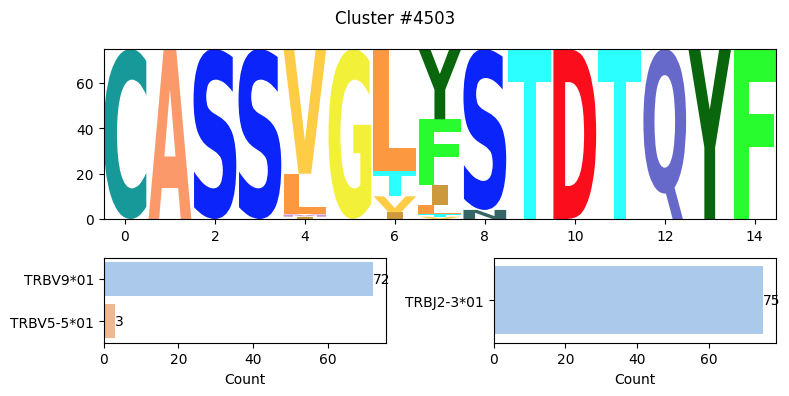

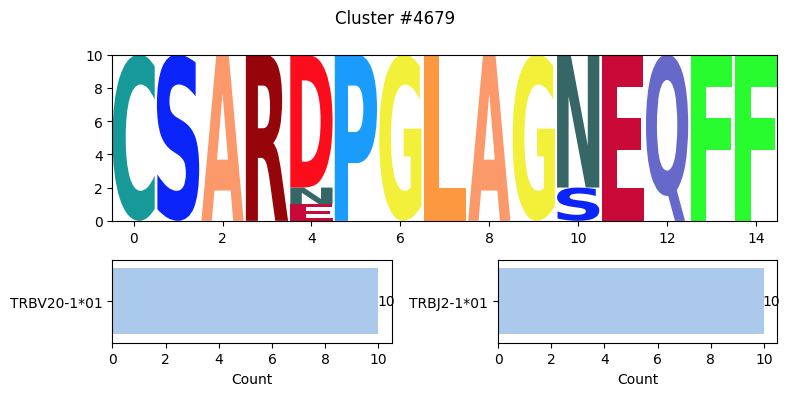

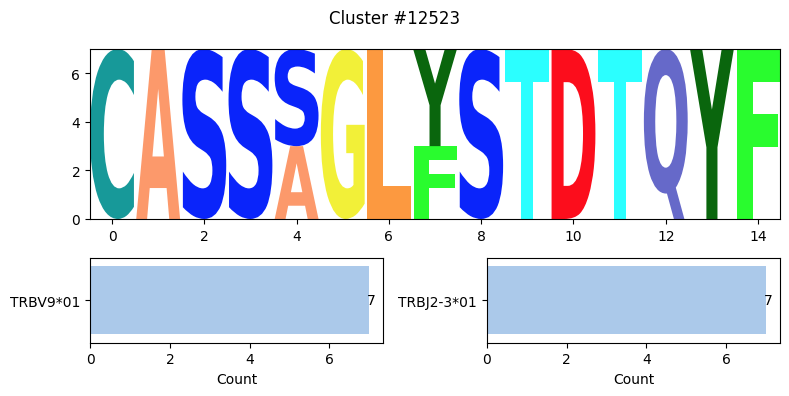

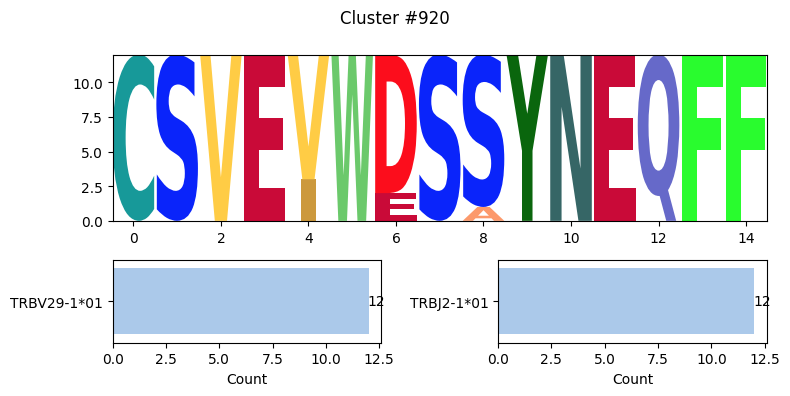

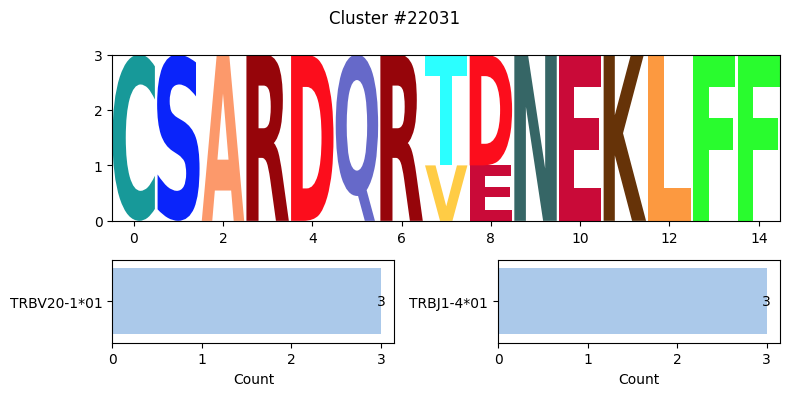

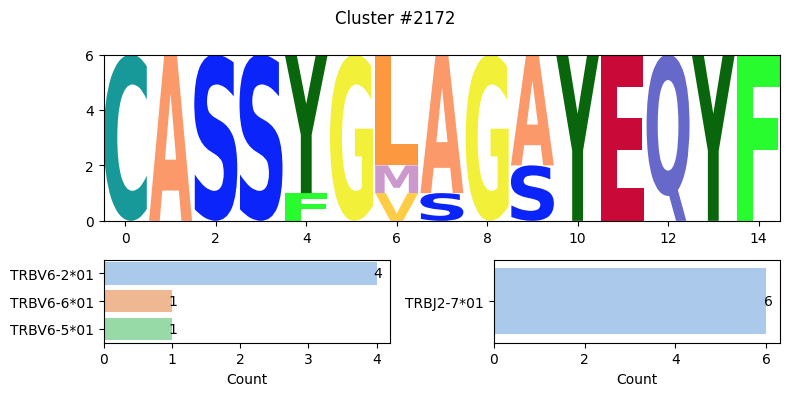

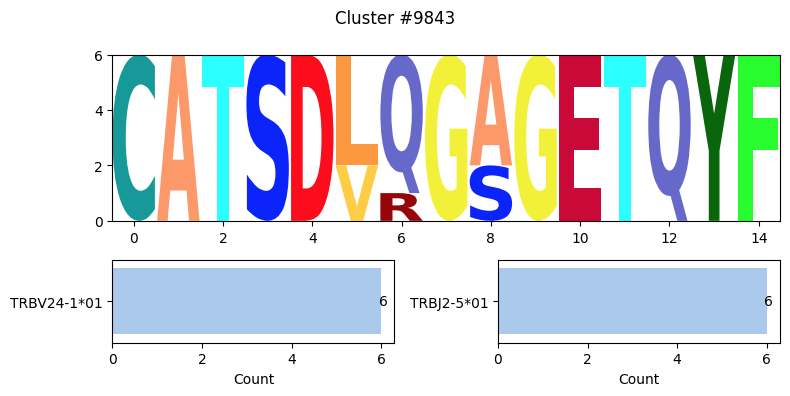

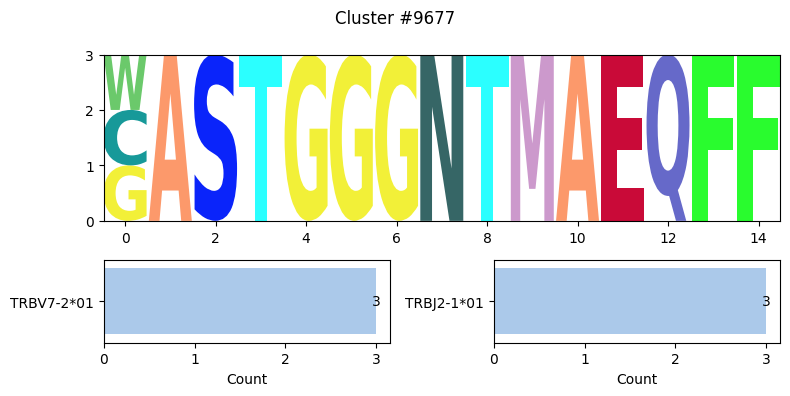

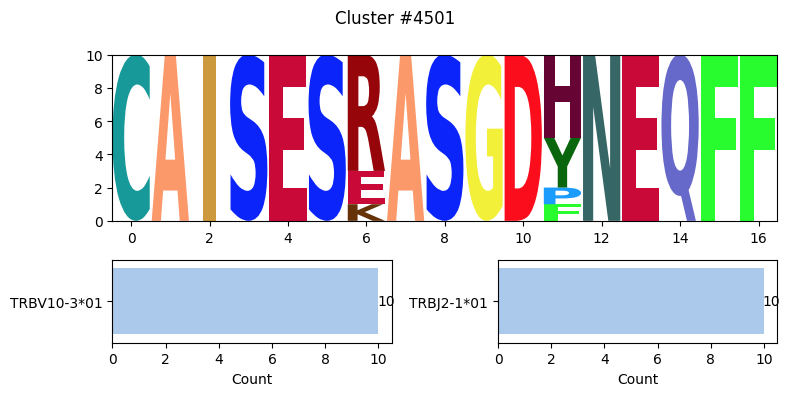

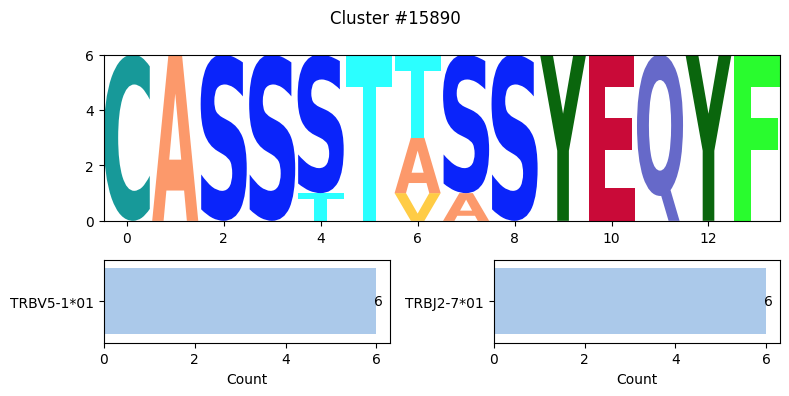

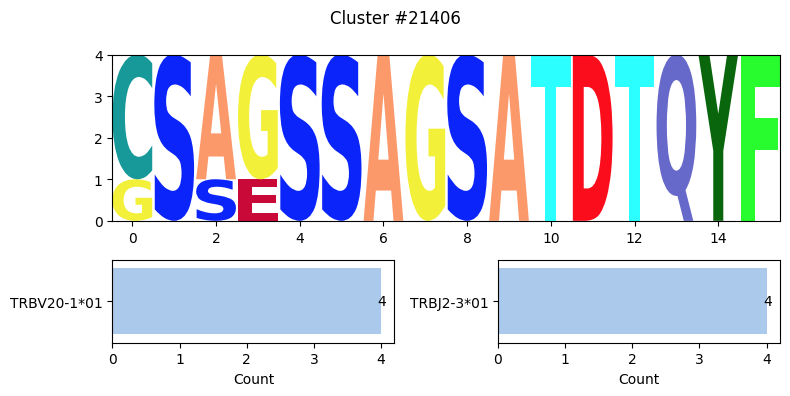

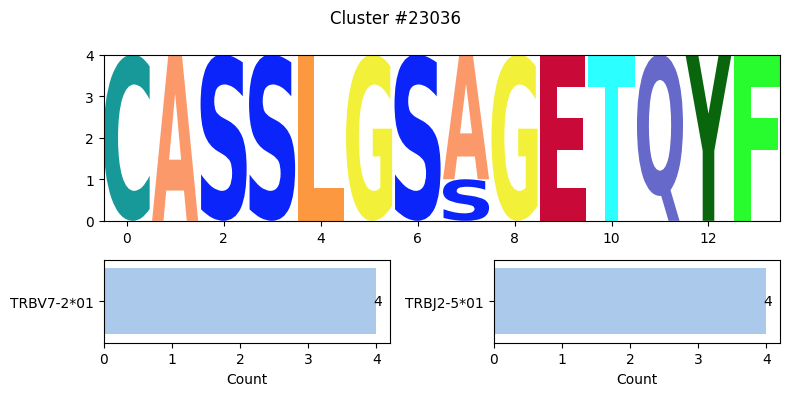

In [188]:
for cluster_id in ranked_df.head(12)['merged_cluster_id']:
    get_cluster_info(df, cluster_id)

In [ ]:
df[(df.merged_cluster_id == 12523)].v_beta.value_counts()

In [131]:
df[(df.merged_cluster_id == 4679)]#.v_beta.value_counts()

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
31788,s_14469,as_Bal_PB_F_c1576,CSARDPGLAGNEQFF,TRBV20-1*01,TRBJ2-1*01,sample,as_Bal_PB_F,False,4679,False,1.330834e-08
34003,s_122546,as_Bal_PB_F_c1576,CSARDPGLAGNEQFF,TRBV20-1*01,TRBJ2-1*01,sample,as_Bal_PB_F,False,4679,False,1.330834e-08
34024,s_123522,as_Bal_PB_F_c1576,CSARDPGLAGNEQFF,TRBV20-1*01,TRBJ2-1*01,sample,as_Bal_PB_F,False,4679,False,1.330834e-08
75184,s_55578,as_Dv_PB_F_c5556,CSARDPGLAGNEQFF,TRBV20-1*01,TRBJ2-1*01,sample,as_Dv_PB_F,False,4679,False,1.330834e-08
76658,s_122144,as_Dv_PB_F_c5556,CSAREPGLAGNEQFF,TRBV20-1*01,TRBJ2-1*01,sample,as_Dv_PB_F,False,4679,False,3.340736e-09
80455,s_319016,as_Dv_PB_F_c5556,CSARDPGLAGNEQFF,TRBV20-1*01,TRBJ2-1*01,sample,as_Dv_PB_F,False,4679,False,1.330834e-08
250590,s_10754,as_Vas_PB_F_c947,CSARDPGLAGNEQFF,TRBV20-1*01,TRBJ2-1*01,sample,as_Vas_PB_F,False,4679,False,1.330834e-08
251496,s_67961,as_Vas_PB_F_c947,CSARDPGLAGNEQFF,TRBV20-1*01,TRBJ2-1*01,sample,as_Vas_PB_F,False,4679,False,1.330834e-08
251509,s_68276,as_Vas_PB_F_c947,CSARDPGLAGSEQFF,TRBV20-1*01,TRBJ2-1*01,sample,as_Vas_PB_F,False,4679,False,1.438324e-09
251518,s_68567,as_Vas_PB_F_c947,CSARNPGLAGSEQFF,TRBV20-1*01,TRBJ2-1*01,sample,as_Vas_PB_F,False,4679,False,9.152800e-11


In [ ]:
plot_logo(df[df.merged_cluster_id == 7446].cdr3aa_beta)

In [ ]:
plot_logo(df[df.merged_cluster_id == 2309].cdr3aa_beta)

In [ ]:
ranked_df[ranked_df['as_pattern']]

In [ ]:
sns.histplot(selected_summary.log_patient_fc)